In [2]:
import os
os.chdir(r'D:\HKUST\5054_Statistical_Machine_Learning\Assignments\HW2')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, KFold, cross_val_score
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

# 读数据
cars = pd.read_csv("cars.csv")
print(cars.columns.tolist())
print(cars.head())
X = cars[['speed']].values  # 取成 DataFrame 再转 numpy array，形状是 (50, 1 )PolynomialFeatures 需要一个 2D 数组
y = cars['dist'].values 
# print(X.head())

['speed', 'dist']
   speed  dist
0      4     2
1      4    10
2      7     4
3      7    22
4      8    16


In [3]:
def poly_cv_mse(X, y, degrees, cv):
    """计算多项式回归的 CV MSE，定义一个function直接调用"""
    mse_list = []
    for d in degrees:
        poly = PolynomialFeatures(degree=d, include_bias=False)
        X_poly = poly.fit_transform(X)
        model = LinearRegression()
        # cross_val_score 返回负的 MSE，所以取负号得到正的 MSE
        neg_mse_scores = cross_val_score(model, X_poly, y, cv=cv, scoring='neg_mean_squared_error')
        mse = -np.mean(neg_mse_scores)  # 平均 CV 误差
        mse_list.append(mse)
    return np.array(mse_list)

The best degree is 2，MSE = 243.03


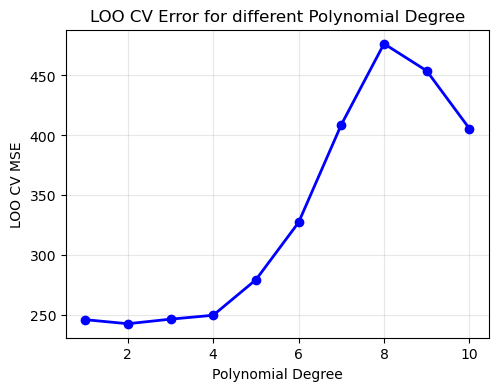

In [4]:
# P3_Q1
#LOO
degrees = np.arange(1, 11)  # degree 1 到 10
loo = LeaveOneOut()  # LOO CV
loo_mse = poly_cv_mse(X, y, degrees, loo)

# plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(degrees, loo_mse, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Polynomial Degree')
plt.ylabel('LOO CV MSE')
plt.title('LOO CV Error for different Polynomial Degree')
plt.grid(True, alpha=0.3)

#find best degree
best_deg_loo = degrees[np.argmin(loo_mse)]
print(f"The best degree is {best_deg_loo}，MSE = {loo_mse.min():.2f}")


The best degree is 1，MSE = 242.74


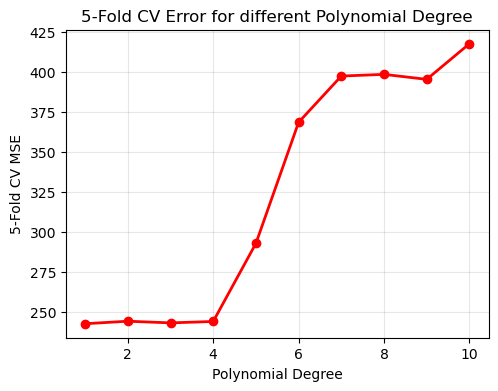

In [5]:
# P3_Q2
# 5-fold
# degrees has been defined at P3_Q1
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
kf5_mse = poly_cv_mse(X, y, degrees, kf5)

#plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(degrees, kf5_mse, 'ro-', linewidth=2, markersize=6)
plt.xlabel('Polynomial Degree')
plt.ylabel('5-Fold CV MSE')
plt.title('5-Fold CV Error for different Polynomial Degree')
plt.grid(True, alpha=0.3)

# find the best degree
best_deg_kf5 = degrees[np.argmin(kf5_mse)]
print(f"The best degree is {best_deg_kf5}，MSE = {kf5_mse.min():.2f}")

# plt.tight_layout()
# plt.show()

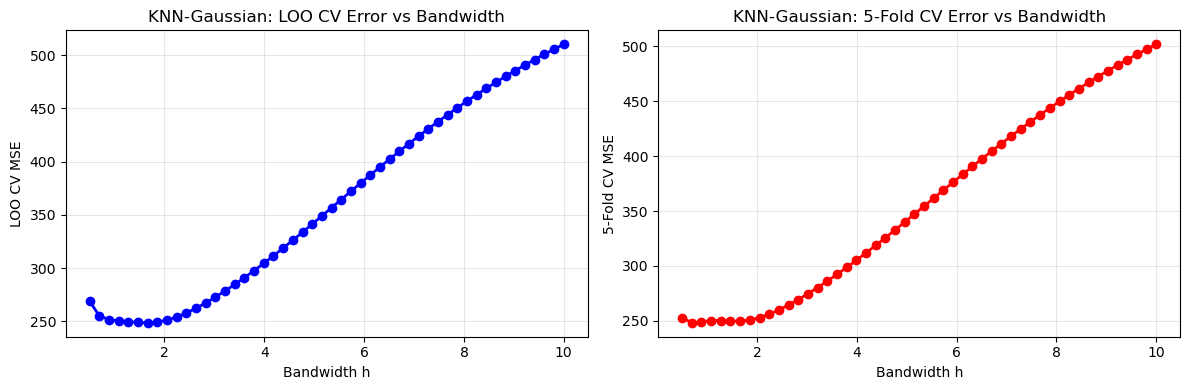

Use LOO CV, best bandwidth = 1.66，MSE = 248.71
Use 5-Fold CV, best bandwidth = 0.69，MSE = 248.14


In [28]:
# P3_Q3
# KNN with Gaussian Kernel + CV
#sklearn 的 KNeighborsRegressor 默认不是高斯核，所以我们需要自定义预测函数
def gaussian_kernel_predict(X_train, y_train, X_test, h):
    """
    使用高斯核进行非参数回归预测。
    对于每个测试点 x，计算其与所有训练点的距离，并用高斯权重加权平均。
    """
    preds = []
    for x in X_test:
        distances = np.abs(X_train.flatten() - x)  # 1D 距离
        weights = np.exp(- (distances ** 2) / (2 * h ** 2))  # 高斯权重
        pred = np.sum(weights * y_train) / np.sum(weights)  # 加权平均
        preds.append(pred)
    return np.array(preds)
    
def knn_gaussian_cv_mse(X, y, h_values, cv):
    """
    对于每个带宽 h，执行交叉验证，返回平均 MSE。
    因为 sklearn 的 cross_val_score 不支持自定义的高斯核模型，所以需要手动实现循环。
    """
    mse_list = []
    for h in h_values:
        fold_mse = []
        for train_idx, val_idx in cv.split(X):  # 获取训练和验证索引
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]
            # 在当前 fold 上预测
            y_pred = gaussian_kernel_predict(X_tr, y_tr, X_val, h)
            # 计算该 fold 的 MSE
            fold_mse.append(mean_squared_error(y_val, y_pred))
        # 计算所有 folds 的平均 MSE
        mse_list.append(np.mean(fold_mse))
    return np.array(mse_list)

# try different bandwidth
h_values = np.linspace(0.5, 10, 50)  # 从 0.5 到 10，共 50 个值

# LOO CV for KNN-Gaussian
loo_mse_knn = knn_gaussian_cv_mse(X, y, h_values, LeaveOneOut())
# 5-Fold CV for KNN-Gaussian
kf5_mse_knn = knn_gaussian_cv_mse(X, y, h_values, KFold(n_splits=5, shuffle=True, random_state=42))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(h_values, loo_mse_knn, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Bandwidth h')
plt.ylabel('LOO CV MSE')
plt.title('KNN-Gaussian: LOO CV Error vs Bandwidth')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(h_values, kf5_mse_knn, 'ro-', linewidth=2, markersize=6)
plt.xlabel('Bandwidth h')
plt.ylabel('5-Fold CV MSE')
plt.title('KNN-Gaussian: 5-Fold CV Error vs Bandwidth')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_h_loo = h_values[np.argmin(loo_mse_knn)]
best_h_kf5 = h_values[np.argmin(kf5_mse_knn)]

print(f"Use LOO CV, best bandwidth = {best_h_loo:.2f}，MSE = {loo_mse_knn.min():.2f}")
print(f"Use 5-Fold CV, best bandwidth = {best_h_kf5:.2f}，MSE = {kf5_mse_knn.min():.2f}")


Under LOOCV
Best polynomial regression (deg=2): MSE = 243.03
Best KNN-Gaussian kernel (h=1.66): MSE = 248.71
Under the LOOCV, polynomial regression have better performance.

Under 5-Fold CV
Best polynomial regression (deg=1): MSE = 242.74
Best KNN-Gaussian kernel (h=0.69): MSE = 248.14
Under the 5-Fold CV, polynomial regression have better performance.

Final result
Both CV methods (LOO and 5-Fold) indicate that the Polynomial model performs better (has a smaller MSE).


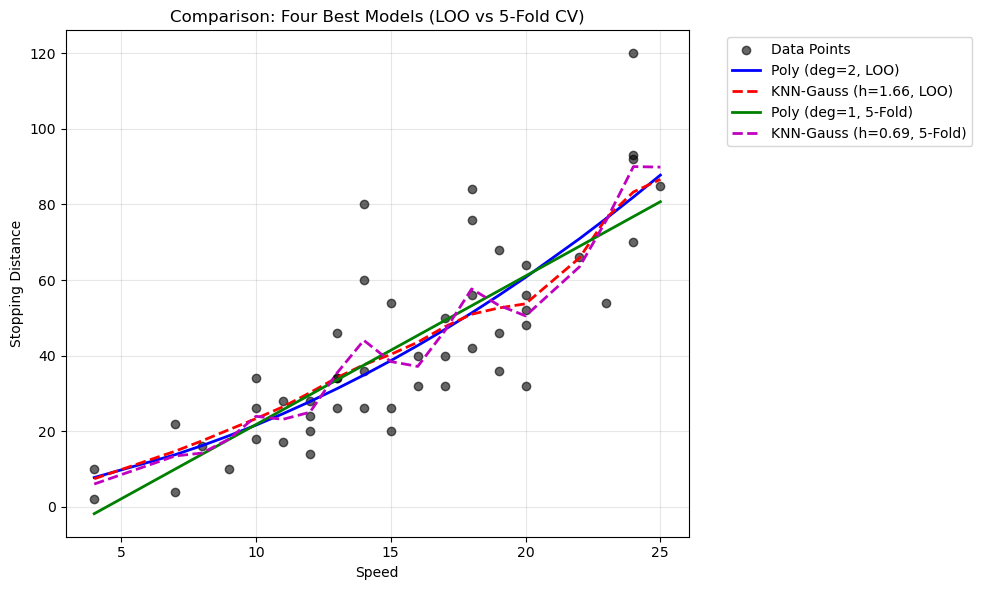

In [39]:
# P3_Q4
# Compare the KNN-Gaussian kernel and polynomial regression
# 分别比较在LOO CV和5-Fold CV下的效果
best_deg_loo = degrees[np.argmin(loo_mse)]
best_deg_kf5 = degrees[np.argmin(kf5_mse)]
best_h_loo = h_values[np.argmin(loo_mse_knn)]
best_h_kf5 = h_values[np.argmin(kf5_mse_knn)]

# 1. 比较 LOO CV 下的性能
print(f"\nUnder LOOCV")
print(f"Best polynomial regression (deg={best_deg_loo}): MSE = {loo_mse.min():.2f}")
print(f"Best KNN-Gaussian kernel (h={best_h_loo:.2f}): MSE = {loo_mse_knn.min():.2f}")
if loo_mse.min() < loo_mse_knn.min():
    print("Under the LOOCV, polynomial regression have better performance.")
    better_model_loo = "Polynomial"
    best_mse_loo = loo_mse.min()
else:
    print("Under the LOOCV, KNN-Gaussian kernel have better performance.")
    better_model_loo = "KNN-Gaussian"
    best_mse_loo = loo_mse_knn.min()

# 2. 比较 5-Fold CV 下的性能
print(f"\nUnder 5-Fold CV")
print(f"Best polynomial regression (deg={best_deg_kf5}): MSE = {kf5_mse.min():.2f}")
print(f"Best KNN-Gaussian kernel (h={best_h_kf5:.2f}): MSE = {kf5_mse_knn.min():.2f}")
if kf5_mse.min() < kf5_mse_knn.min():
    print("Under the 5-Fold CV, polynomial regression have better performance.")
    better_model_kf5 = "Polynomial"
    best_mse_kf5 = kf5_mse.min()
else:
    print("Under the 5-Fold CV, KNN-Gaussian kernel have better performance.")
    better_model_kf5 = "KNN-Gaussian"
    best_mse_kf5 = kf5_mse_knn.min()

# 3. 比较两种CV下的选择
print(f"\nFinal result")
if better_model_loo == better_model_kf5:
    print(f"Both CV methods (LOO and 5-Fold) indicate that the {better_model_loo} model performs better (has a smaller MSE).")
else:
    print(f"LOO CV suggests the {better_model_loo} model is better, whereas 5-Fold CV suggests the {better_model_kf5} model is better.")

# 4. 画图
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', alpha=0.6, label='Data Points', zorder=5)

X_sorted = np.sort(X, axis=0)

# 最优多项式模型 (LOO)
poly_best_loo = PolynomialFeatures(degree=best_deg_loo, include_bias=False)
X_poly_best_loo = poly_best_loo.fit_transform(X)
model_poly_loo = LinearRegression().fit(X_poly_best_loo, y)
X_poly_sorted_loo = poly_best_loo.transform(X_sorted)
y_poly_sorted_loo = model_poly_loo.predict(X_poly_sorted_loo)
plt.plot(X_sorted, y_poly_sorted_loo, 'b-', linewidth=2, label=f'Poly (deg={best_deg_loo}, LOO)', zorder=10)

# 最优 KNN-Gaussian 模型 (LOO)
y_knn_sorted_loo = gaussian_kernel_predict(X, y, X_sorted, best_h_loo) 
plt.plot(X_sorted, y_knn_sorted_loo, 'r--', linewidth=2, label=f'KNN-Gauss (h={best_h_loo:.2f}, LOO)', zorder=10)

# 最优多项式模型 (5-Fold) 
poly_best_kf5 = PolynomialFeatures(degree=best_deg_kf5, include_bias=False)
X_poly_best_kf5 = poly_best_kf5.fit_transform(X)
model_poly_kf5 = LinearRegression().fit(X_poly_best_kf5, y)
X_poly_sorted_kf5 = poly_best_kf5.transform(X_sorted)
y_poly_sorted_kf5 = model_poly_kf5.predict(X_poly_sorted_kf5)
plt.plot(X_sorted, y_poly_sorted_kf5, 'g-', linewidth=2, label=f'Poly (deg={best_deg_kf5}, 5-Fold)', zorder=10)

# 最优 KNN-Gaussian 模型 (5-Fold) 
y_knn_sorted_kf5 = gaussian_kernel_predict(X, y, X_sorted, best_h_kf5) 
plt.plot(X_sorted, y_knn_sorted_kf5, 'm--', linewidth=2, label=f'KNN-Gauss (h={best_h_kf5:.2f}, 5-Fold)', zorder=10)

plt.xlabel('Speed')
plt.ylabel('Stopping Distance')
plt.title('Comparison: Four Best Models (LOO vs 5-Fold CV)')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1)) 
plt.grid(True, alpha=0.3)
plt.tight_layout()  # 自动调整子图间距，防止图例被裁剪
plt.show()